# Customer Churn

### Importing Necessary Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import pickle

### Data Loading and Understanding

In [2]:
churn_df = pd.read_csv('Customer-Churn.csv')

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
churn_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
# Dropping customerID column as it is not useful for prediction
churn_df.drop('customerID', axis=1, inplace=True)

In [7]:
for column in churn_df.select_dtypes(include=['object']).columns:
    print(f"{column}: {churn_df[column].unique()}\n")

gender: ['Female' 'Male']

Partner: ['Yes' 'No']

Dependents: ['No' 'Yes']

PhoneService: ['No' 'Yes']

MultipleLines: ['No phone service' 'No' 'Yes']

InternetService: ['DSL' 'Fiber optic' 'No']

OnlineSecurity: ['No' 'Yes' 'No internet service']

OnlineBackup: ['Yes' 'No' 'No internet service']

DeviceProtection: ['No' 'Yes' 'No internet service']

TechSupport: ['No' 'Yes' 'No internet service']

StreamingTV: ['No' 'Yes' 'No internet service']

StreamingMovies: ['No' 'Yes' 'No internet service']

Contract: ['Month-to-month' 'One year' 'Two year']

PaperlessBilling: ['Yes' 'No']

PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

TotalCharges: ['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']

Churn: ['No' 'Yes']



In [8]:
churn_df.TotalCharges = pd.to_numeric(churn_df.TotalCharges, errors='coerce')

In [9]:
churn_df.isna().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [10]:
churn_df[churn_df['TotalCharges'].isna()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [11]:
# Total Charges has 11 missing values to which tenure is 0, meaning these are new customers. We can safely fill these missing values with 0.
churn_df['TotalCharges'].fillna(0, inplace =True)

/var/folders/y9/54zzfyhs7f72c0_0zfrb98yr0000gn/T/ipykernel_50850/3446237946.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  churn_df['TotalCharges'].fillna(0, inplace =True)


In [12]:
churn_df.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Insights
1. CustomerId is removed as it is not required for modelling.
2. No missing values in the dataset.
3. TotalCharges was in object data type, which was then converted to numeric, and the missing values were replaced with 0, as the customers were new and their tenure was 0.
4. Class imbalance identified in the target column.

### Exploratory Data Analysis (EDA)

In [13]:
churn_df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


In [14]:
churn_df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


### Plotting Distribution Plots

In [15]:
# Plotting the distribution of numerical features
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

def plot_numerical_distribution(df, features):
    
    plt.figure(figsize=(15, 5))
    sns.histplot(data=df[features], kde=True)
    plt.title(f'Distribution of {features}')

    # calculating mean and median
    col_mean = df[features].mean()
    col_median = df[features].median()

    # plotting mean and median lines
    plt.axvline(col_mean, color='r', linestyle='--', label='Mean')
    plt.axvline(col_median, color='g', linestyle='-', label='Median')
    plt.legend()
    plt.show()

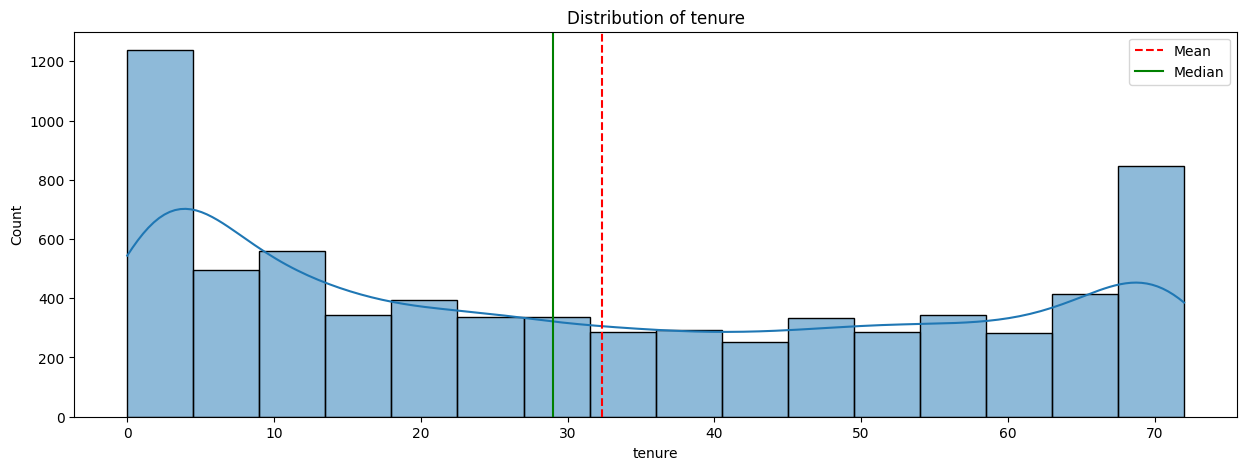

In [16]:
plot_numerical_distribution(churn_df, numerical_features[0])

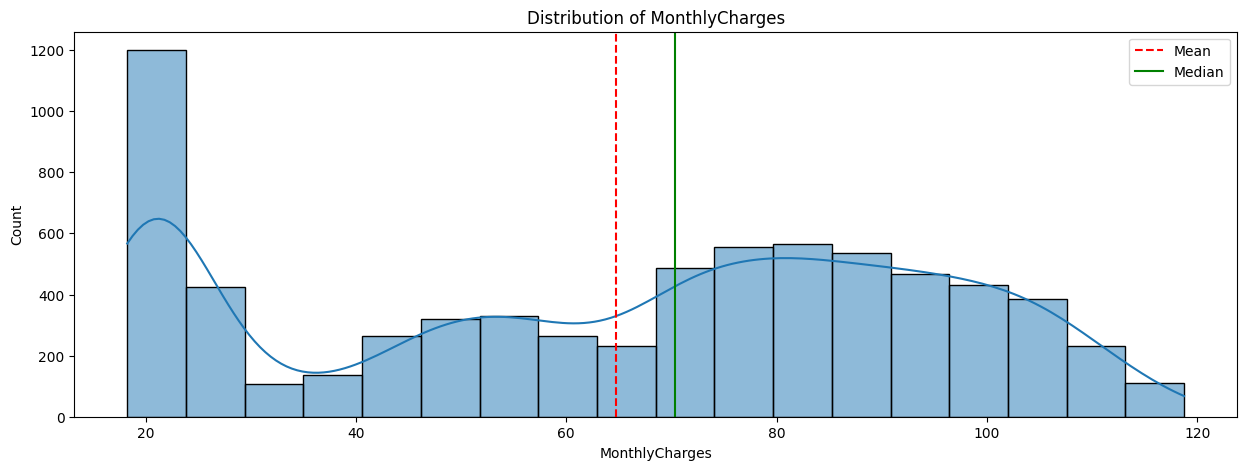

In [17]:
plot_numerical_distribution(churn_df, numerical_features[1])

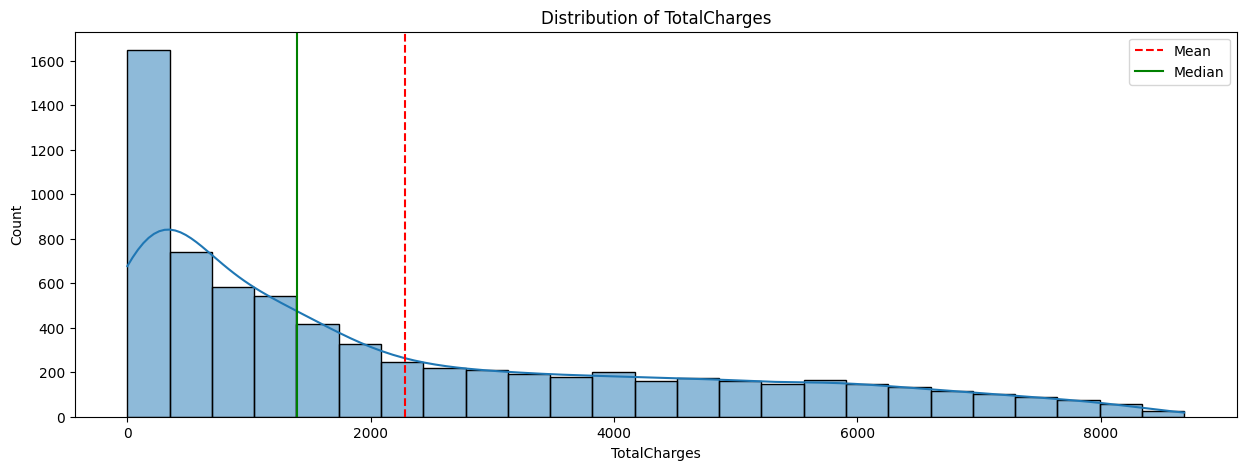

In [18]:
plot_numerical_distribution(churn_df, numerical_features[2])

### Ploting Box Plots

In [19]:
def plot_boxplot(df, features):

    plt.figure(figsize=(7, 5))
    sns.boxplot(df[features])
    plt.title(f'Boxplot of {features}')
    plt.show()

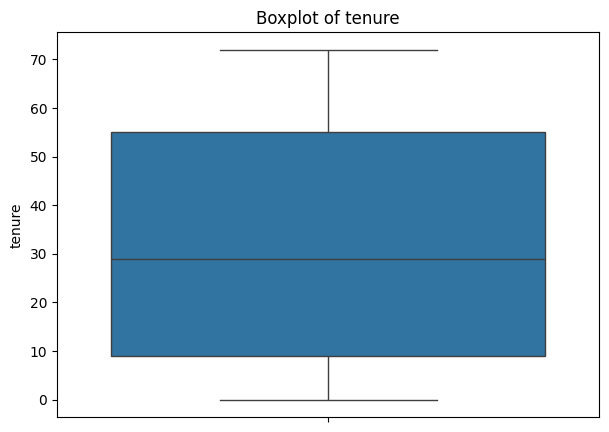

In [20]:
plot_boxplot(churn_df, numerical_features[0])

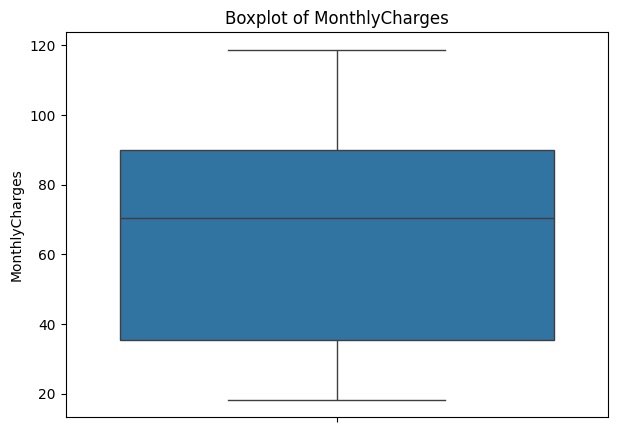

In [21]:
plot_boxplot(churn_df, numerical_features[1])

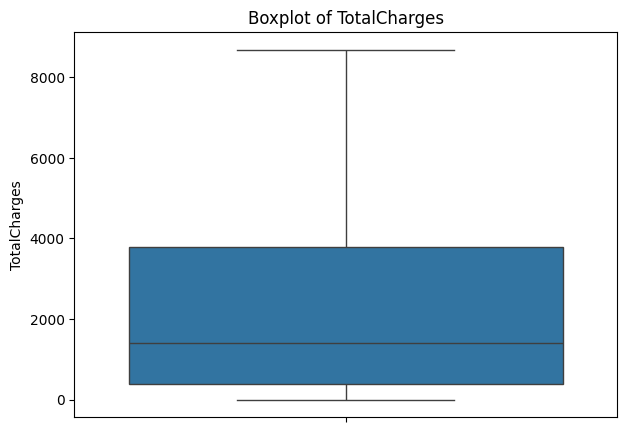

In [22]:
plot_boxplot(churn_df, numerical_features[2])

##### There are no outliers in the numerical dataset.

### Correlation Heatmap

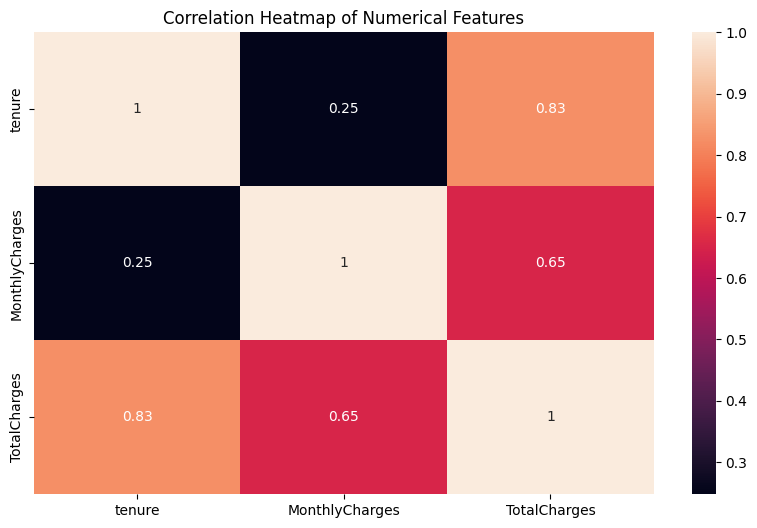

In [23]:
plt.figure(figsize=(10, 6))
sns.heatmap(churn_df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(), annot=True)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

#### Categorical Features Analysis

In [6]:
churn_df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
object_cols = churn_df.select_dtypes(include="object").columns.to_list()
object_cols += ['SeniorCitizen']
object_cols

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'TotalCharges',
 'Churn',
 'SeniorCitizen']

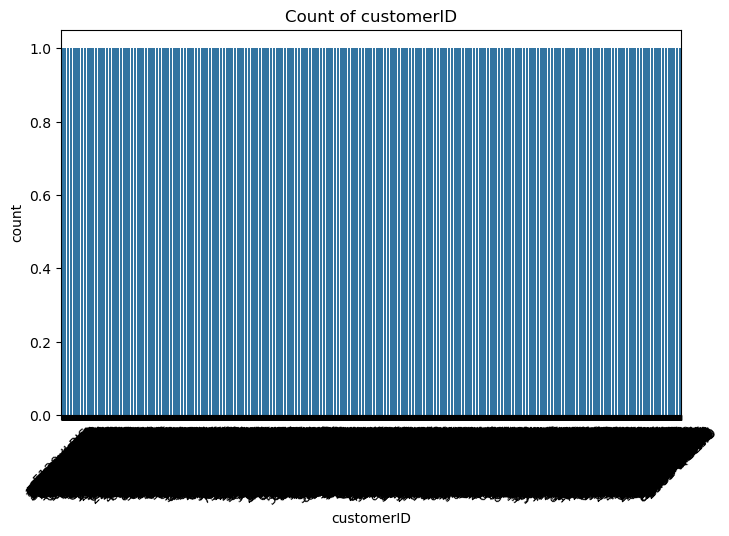

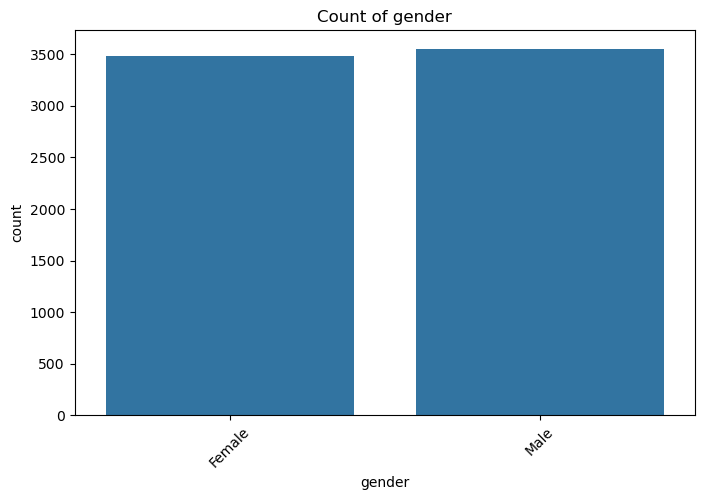

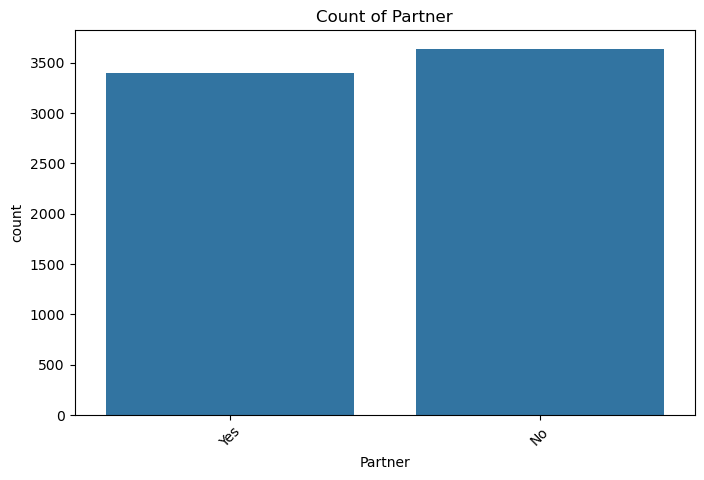

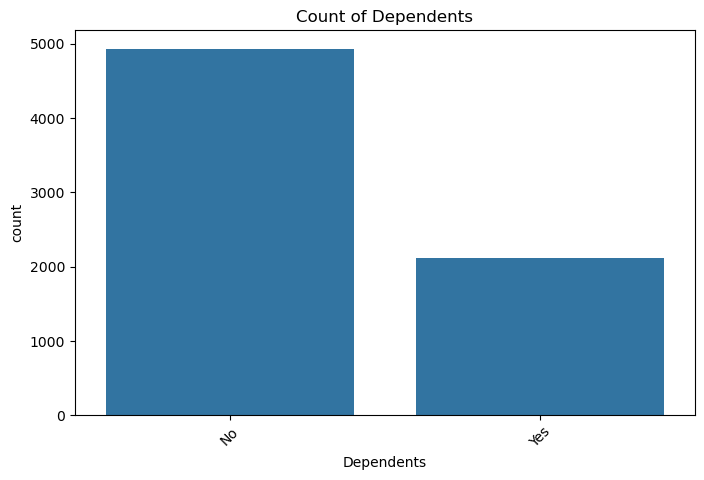

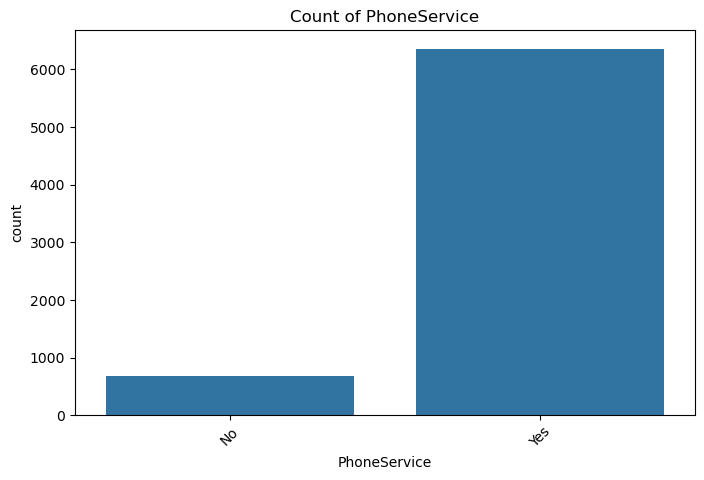

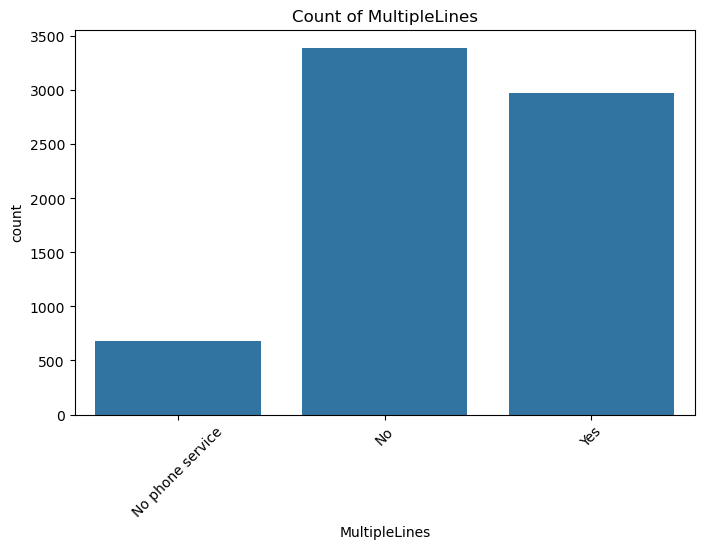

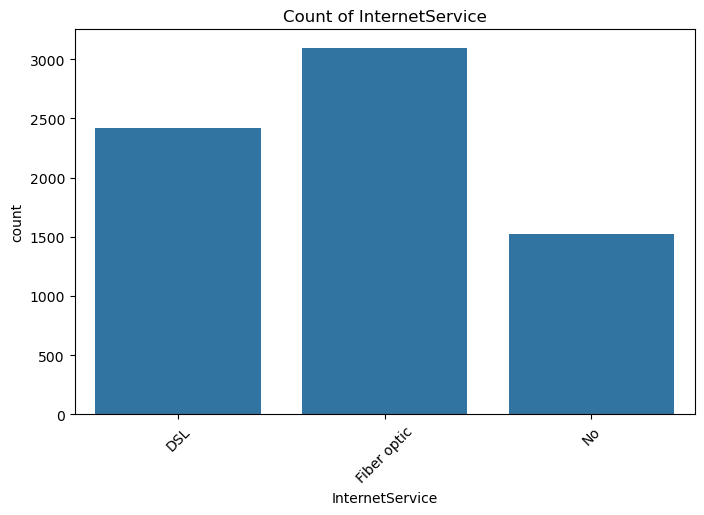

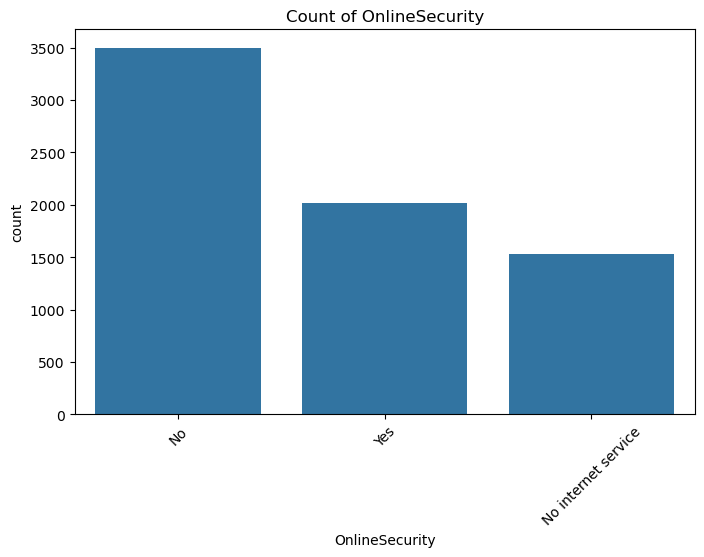

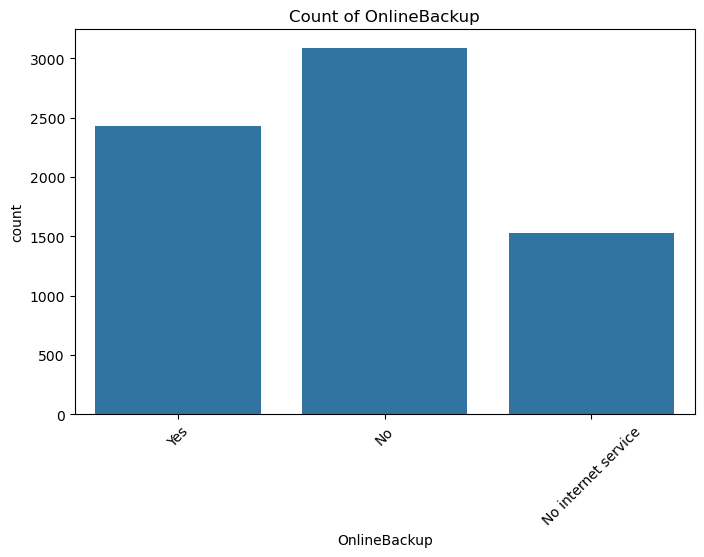

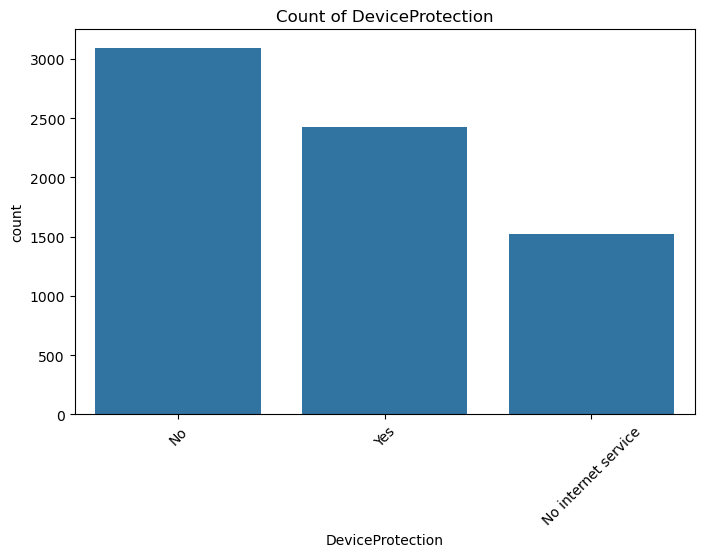

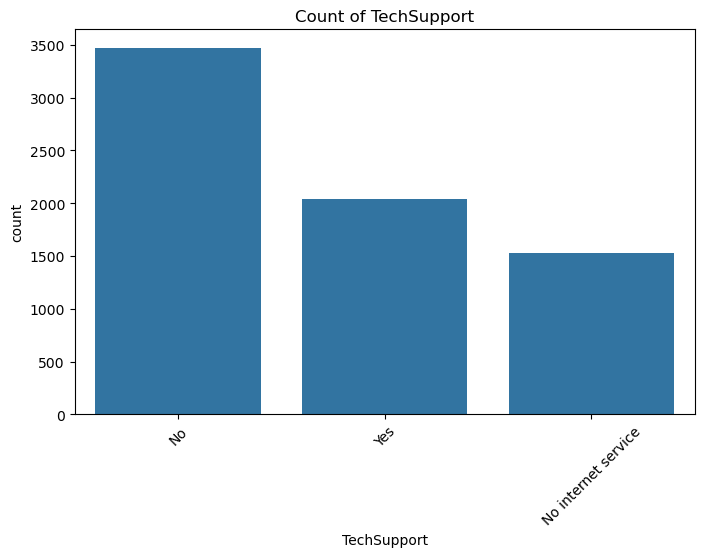

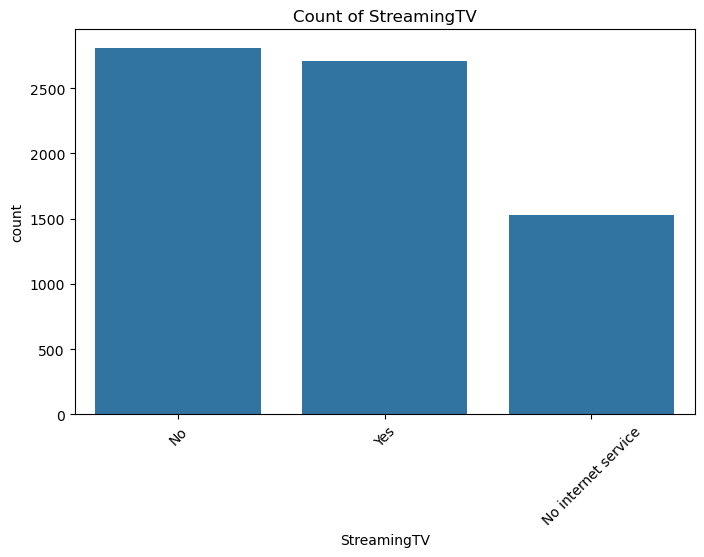

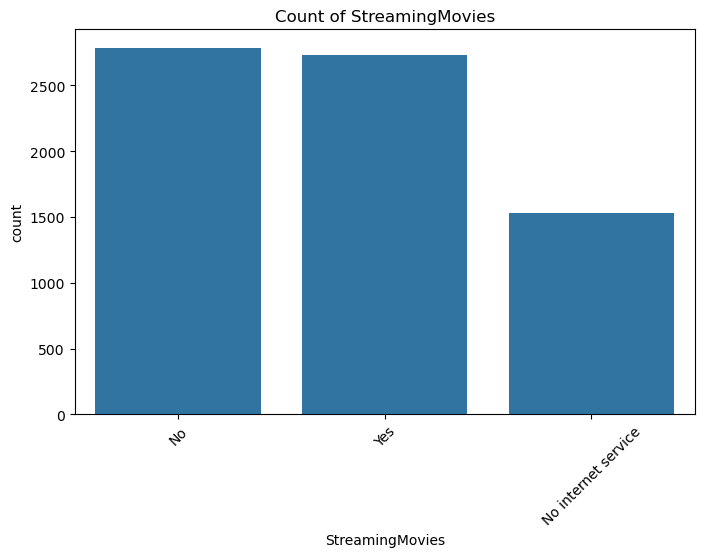

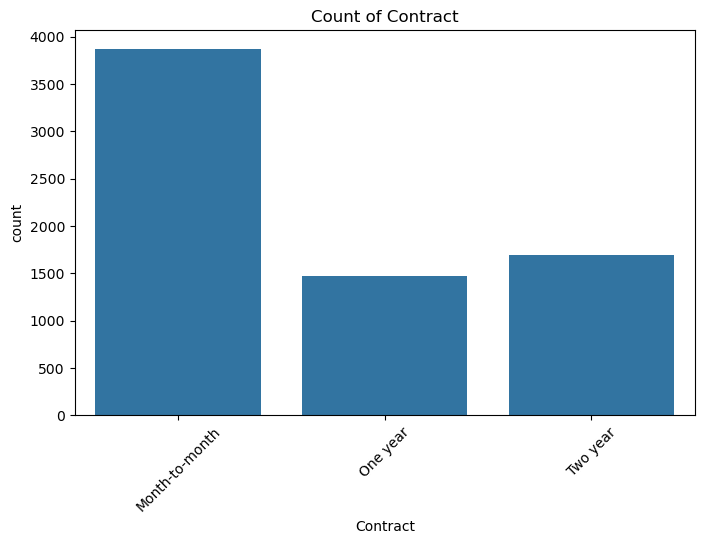

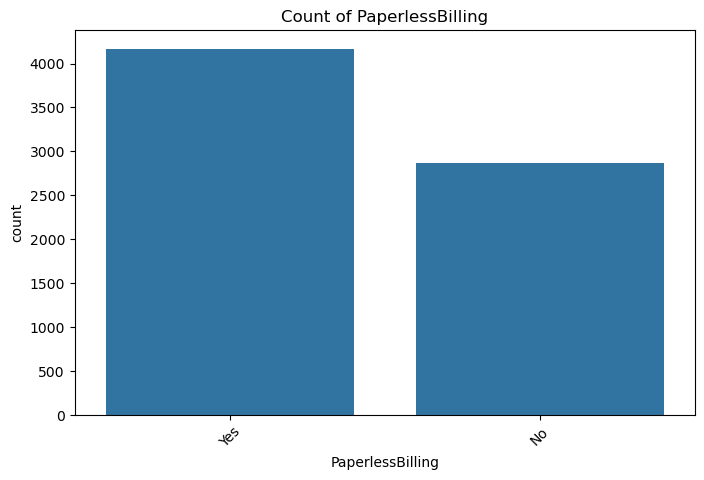

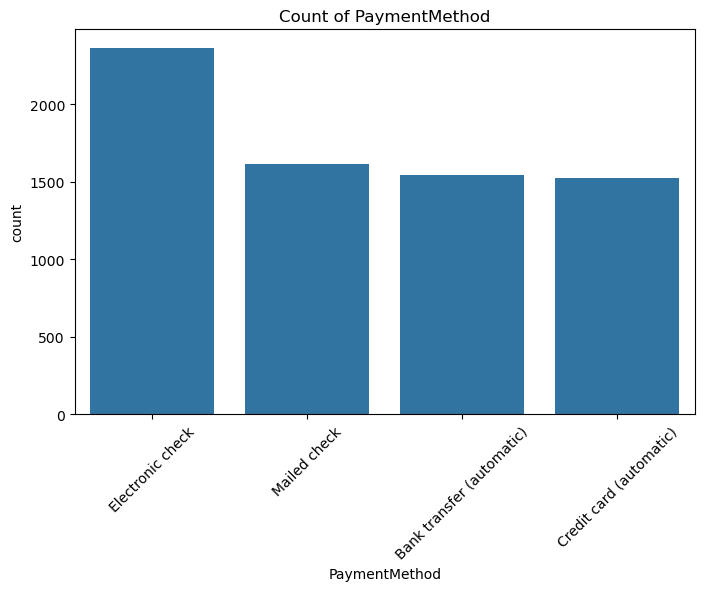

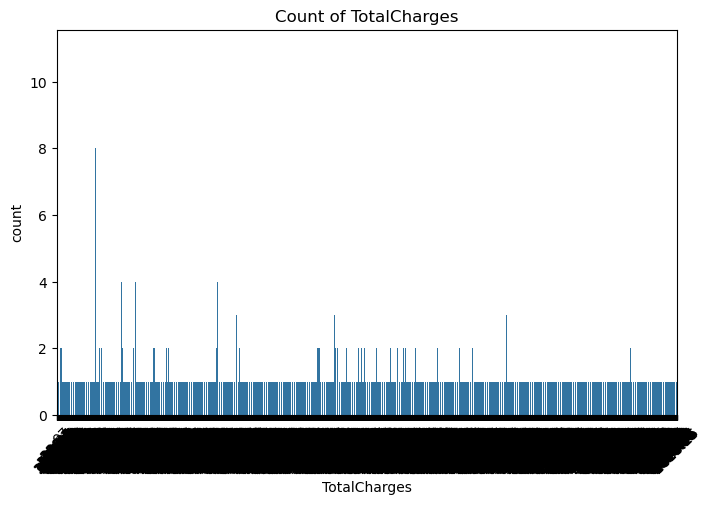

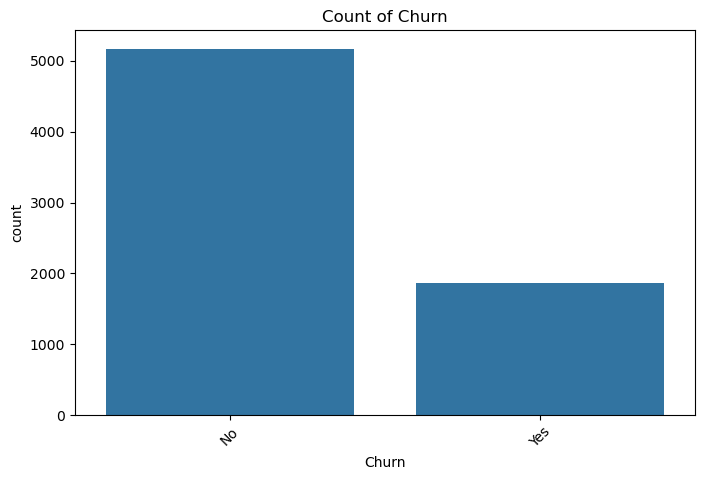

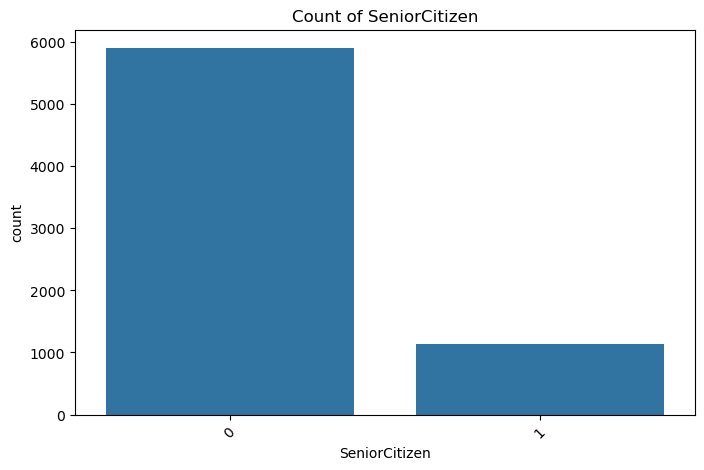

In [10]:
for col in object_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=churn_df, x=col)
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45)
    plt.show()

### Data Preprocessing

In [27]:
churn_df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


Encoding the target column

In [28]:
churn_df["Churn"] = churn_df["Churn"].map({'Yes': 1, "No" : 0})

In [29]:
churn_df.Churn.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

### Encoding Other Categorical Columns

In [30]:
object_cols = churn_df.select_dtypes(include="object").columns.to_list()
object_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [31]:
# Initialise a dictionary to save the encoders
encoders = {}

for col in object_cols:
    ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
    
    encoded = ohe.fit_transform(churn_df[[col]])
    feature_names = ohe.get_feature_names_out([col])
    
    encoded_df = pd.DataFrame(encoded, columns=feature_names, index=churn_df.index)
    
    churn_df = pd.concat([churn_df.drop(col, axis=1), encoded_df], axis=1)
    
    encoders[col] = ohe

# Save encoders
with open('encoder.pkl', 'wb') as f:
    pickle.dump(encoders, f)

In [32]:
encoders

{'gender': OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False),
 'Partner': OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False),
 'Dependents': OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False),
 'PhoneService': OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False),
 'MultipleLines': OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False),
 'InternetService': OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False),
 'OnlineSecurity': OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False),
 'OnlineBackup': OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False),
 'DeviceProtection': OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False),
 'TechSupport': OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False),
 'StreamingTV': OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=F

In [33]:
churn_df.head(3)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0,34,56.95,1889.50,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0,2,53.85,108.15,1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


### Train and Test Data Split

In [34]:
# Splitting the data into features and target variable
X = churn_df.drop('Churn', axis=1)
y = churn_df['Churn']

In [35]:
X.head(2)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0,34,56.95,1889.50,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [36]:
y.head(2)

0    0
1    0
Name: Churn, dtype: int64

In [37]:
# splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify=y)

In [38]:
y_train.value_counts()

Churn
0    4139
1    1495
Name: count, dtype: int64

### Model Training

#### A. Logistic Regression - SMOTE vs class_weight

#### Logistic Regression + SMOTE + Scaling

Recall with SMOTE: 0.7919732441471572
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

--------------------------------------------------------------------------------


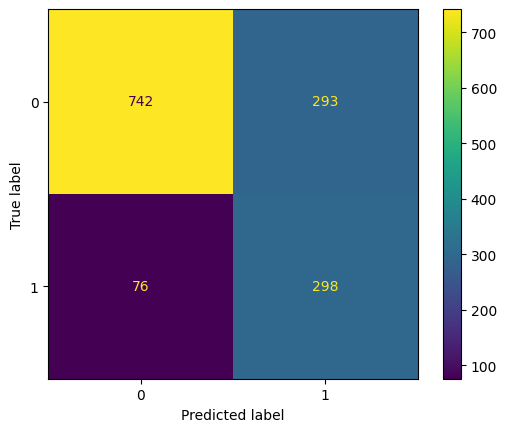

In [39]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# SMOTE
pipe_SMOTE = Pipeline([
    ('scalar', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=1000))
])

score_smote = cross_val_score(pipe_SMOTE, X_train, y_train, cv=cv, scoring='recall')

print(f'Recall with SMOTE: {np.mean(score_smote)}')
print("--"* 40)
print(classification_report(y_test, pipe_SMOTE.fit(X_train, y_train).predict(X_test)))
print("--"* 40)

cm = confusion_matrix(y_test, pipe_SMOTE.fit(X_train, y_train).predict(X_test))
disp = ConfusionMatrixDisplay(cm, display_labels=pipe_SMOTE.classes_)
disp.plot()


#### Logistic Regression + class weight + scaling

Recall with Class Weighting: 0.8006688963210703
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

--------------------------------------------------------------------------------


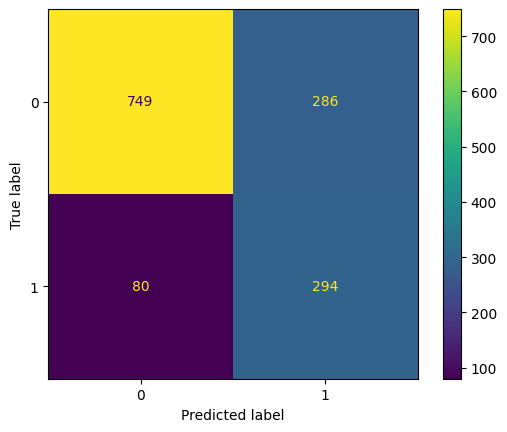

In [40]:
pipe_cw = Pipeline([
    ('scalar', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000))
])

score_cw = cross_val_score(pipe_cw, X_train, y_train, cv=cv, scoring='recall')

print("Recall with Class Weighting:", score_cw.mean())

print("--"* 40)
print(classification_report(y_test, pipe_cw.fit(X_train, y_train).predict(X_test)))
print("--"* 40)

cm = confusion_matrix(y_test, pipe_cw.fit(X_train, y_train).predict(X_test))
disp = ConfusionMatrixDisplay(cm, display_labels=pipe_cw.classes_)
disp.plot()

### Decision Tree - SMOTE vs class weight

#### Decision Tree + SMOTE 

Decision Tree + SMOTE Recall: 0.5070234113712375
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.82      0.81      0.82      1035
           1       0.50      0.52      0.51       374

    accuracy                           0.73      1409
   macro avg       0.66      0.66      0.66      1409
weighted avg       0.74      0.73      0.73      1409

--------------------------------------------------------------------------------


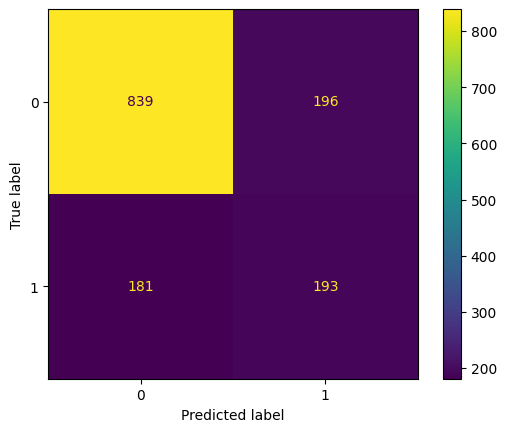

In [41]:
dt_smote = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', DecisionTreeClassifier(random_state=42))
])

score_dt_smote = cross_val_score(
    dt_smote, X_train, y_train, cv=cv, scoring='recall'
)

print("Decision Tree + SMOTE Recall:", score_dt_smote.mean())
print("--"* 40)

dt_smote.fit(X_train, y_train)
y_pred = dt_smote.predict(X_test)

print(classification_report(y_test, y_pred))
print("--"* 40)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=dt_smote.classes_)
disp.plot()

#### Decision Tree + class weigth

Decision Tree + class_weight Recall: 0.8033444816053512
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409

--------------------------------------------------------------------------------


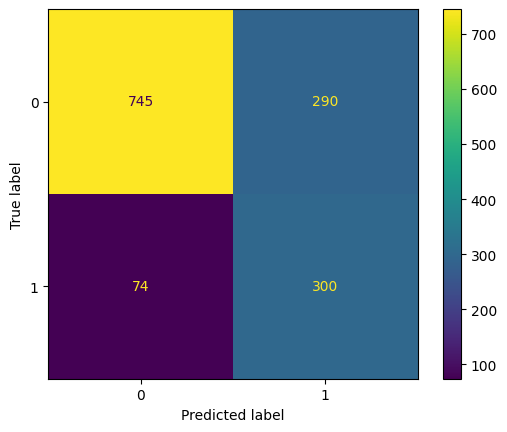

In [42]:
dt_cw = Pipeline([
    ('model', DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42,
        max_depth=6,
        min_samples_leaf=10
    ))
])

score_dt_cw = cross_val_score(
    dt_cw, X_train, y_train, cv=cv, scoring='recall'
)

print("Decision Tree + class_weight Recall:", score_dt_cw.mean())
print("--"* 40)

dt_cw.fit(X_train, y_train)
y_pred = dt_cw.predict(X_test)

print(classification_report(y_test, y_pred))
print("--"* 40)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=dt_cw.classes_)
disp.plot()

### Random Forest - SMOTE vs class weight

#### Random Forest + SMOTE

Random Forest + SMOTE Recall: 0.5090301003344482
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1035
           1       0.61      0.51      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409

--------------------------------------------------------------------------------


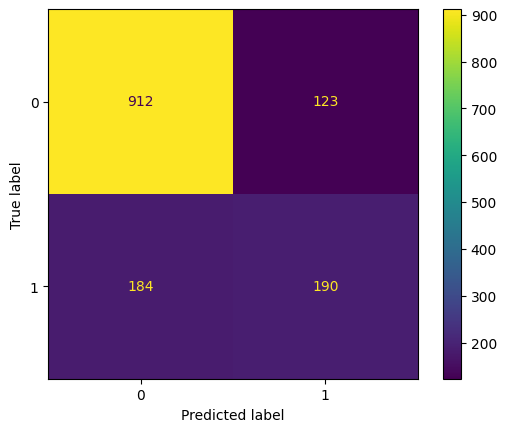

In [43]:
rf_smote = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42, n_estimators=200))
])

score_rf_smote = cross_val_score(
    rf_smote, X_train, y_train, cv=cv, scoring='recall')

print("Random Forest + SMOTE Recall:", score_rf_smote.mean())
print("--"* 40)

rf_smote.fit(X_train, y_train)
y_pred = rf_smote.predict(X_test)

print(classification_report(y_test, y_pred))
print("--"* 40)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=rf_smote.classes_)
disp.plot()

#### Random Forest + class weight

Random Forest + class_weight Recall: 0.4662207357859532
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409

--------------------------------------------------------------------------------


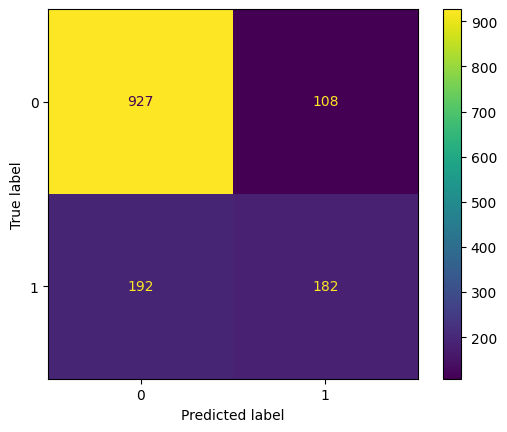

In [44]:
rf_cw = Pipeline([
    ('model', RandomForestClassifier(random_state=42, n_estimators=200, class_weight='balanced'))
])

score_rf_cw = cross_val_score(
    rf_cw, X_train, y_train, cv=cv, scoring='recall')

print("Random Forest + class_weight Recall:", score_rf_cw.mean())
print("--"* 40)

rf_cw.fit(X_train, y_train)
y_pred = rf_cw.predict(X_test)

print(classification_report(y_test, y_pred))
print("--"* 40)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=rf_cw.classes_)
disp.plot()

### XGBoost - SMOTE vs class weight

#### XGBoost + SMOTE

XGBoost + SMOTE Recall: 0.5317725752508361
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1035
           1       0.61      0.56      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.72      0.72      1409
weighted avg       0.78      0.79      0.79      1409

--------------------------------------------------------------------------------


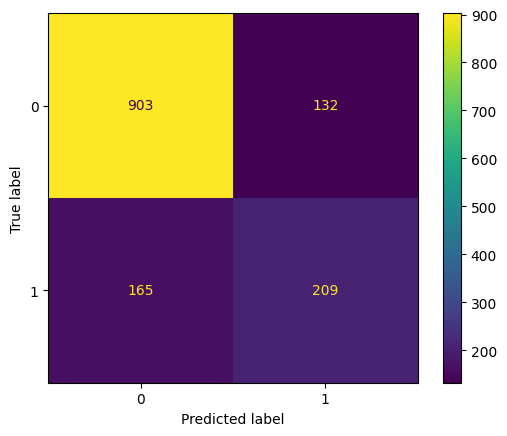

In [45]:
xgb_smote = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ))
])

score_xgb_smote = cross_val_score(
    xgb_smote, X_train, y_train, cv=cv, scoring='recall'
)

print("XGBoost + SMOTE Recall:", score_xgb_smote.mean())
print("--"* 40)

xgb_smote.fit(X_train, y_train)
y_pred = xgb_smote.predict(X_test)

print(classification_report(y_test, y_pred))
print("--"* 40)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=xgb_smote.classes_)
disp.plot()

#### XGBoost + class weight

XGBoost + scale_pos_weight Recall: 0.662876254180602
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1035
           1       0.53      0.70      0.60       374

    accuracy                           0.76      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.79      0.76      0.77      1409

--------------------------------------------------------------------------------


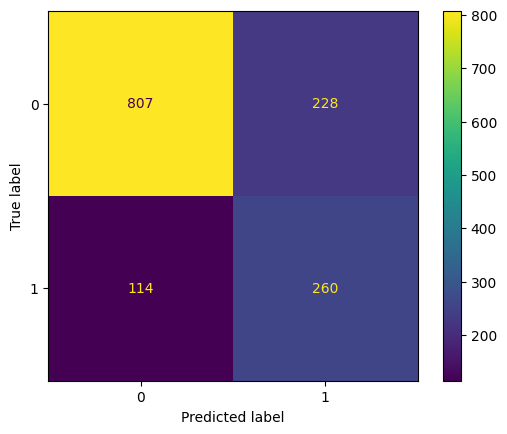

In [46]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

xgb_spw = Pipeline([
    ('model', XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight
    ))
])

score_xgb_spw = cross_val_score(
    xgb_spw, X_train, y_train, cv=cv, scoring='recall'
)

print("XGBoost + scale_pos_weight Recall:", score_xgb_spw.mean())
print("--"* 40)

xgb_spw.fit(X_train, y_train)
y_pred = xgb_spw.predict(X_test)

print(classification_report(y_test, y_pred))
print("--"* 40)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=xgb_spw.classes_)
disp.plot()

### What metric to decide?
#### For telecom churn, the business reality is:
- False Negative (missed churners) = very costly
- Flase Positive (flagged but not churned) = acceptable


### Decision Tree + class weight is the best choice with higest recall, lowest missed churners.

In [47]:
# final training
dt_cw.fit(X_train, y_train)

# saving the model
with open('final_churn_model.pkl', 'wb') as f:
    pickle.dump(dt_cw, f)

In [48]:
# Loading the saved model
with open('final_churn_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# verifying the loaded model
print(loaded_model)

Pipeline(steps=[('model',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=6,
                                        min_samples_leaf=10,
                                        random_state=42))])


In [49]:
y_pred = loaded_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



In [50]:
input_data = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 1,
    'PhoneService': 'No',
    'MultipleLines': 'No phone service',
    'InternetService': 'DSL',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 29.85,
    'TotalCharges': 29.85
}

input_data_df = pd.DataFrame([input_data])

with open('encoder.pkl', 'rb') as f:
    encoders = pickle.load(f)


# encode the categorical features using the saved encoders
for col, encoder in encoders.items():
    encoded = encoder.transform(input_data_df[[col]])
    feature_names = encoder.get_feature_names_out([col])
    
    encoded_df = pd.DataFrame(
        encoded,
        columns=feature_names,
        index=input_data_df.index)
    

    input_data_df = pd.concat(
        [input_data_df.drop(col, axis=1), encoded_df],
        axis=1
    )

# Extract expected feature names from model
if hasattr(loaded_model, "feature_names_in_"):
    expected_features = loaded_model.feature_names_in_
else:
    raise ValueError("Model does not store feature names. Cannot align features safely.")


# Align input data
# -----------------------------
input_data_df = input_data_df.reindex(
    columns=expected_features,
    fill_value=0
)

prediction = loaded_model.predict(input_data_df)
probability = loaded_model.predict_proba(input_data_df)[:, 1]

print(f"Prediction: {'churn' if prediction[0] == 1 else 'no churn'}")
print(f"Churn Probability: {probability[0]:.4f}")


Prediction: churn
Churn Probability: 0.7608


In [54]:
input_data = {
    'gender': 'Male',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'Yes',
    'tenure': 48,
    'PhoneService': 'Yes',
    'MultipleLines': 'Yes',
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'Yes',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'Yes',
    'TechSupport': 'Yes',
    'StreamingTV': 'Yes',
    'StreamingMovies': 'Yes',
    'Contract': 'Two year',
    'PaperlessBilling': 'No',
    'PaymentMethod': 'Credit card (automatic)',
    'MonthlyCharges': 85.0,
    'TotalCharges': 4000.0
}

input_data_df = pd.DataFrame([input_data])

with open('encoder.pkl', 'rb') as f:
    encoders = pickle.load(f)


# encode the categorical features using the saved encoders
for col, encoder in encoders.items():
    encoded = encoder.transform(input_data_df[[col]])
    feature_names = encoder.get_feature_names_out([col])
    
    encoded_df = pd.DataFrame(
        encoded,
        columns=feature_names,
        index=input_data_df.index)
    

    input_data_df = pd.concat(
        [input_data_df.drop(col, axis=1), encoded_df],
        axis=1
    )

# Extract expected feature names from model
if hasattr(loaded_model, "feature_names_in_"):
    expected_features = loaded_model.feature_names_in_
else:
    raise ValueError("Model does not store feature names. Cannot align features safely.")


# Align input data
# -----------------------------
input_data_df = input_data_df.reindex(
    columns=expected_features,
    fill_value=0
)

prediction = loaded_model.predict(input_data_df)
probability = loaded_model.predict_proba(input_data_df)

print(f"Prediction: {'churn' if prediction[0] == 1 else 'no churn'}")
print(f"Churn Probability: {probability}")


Prediction: no churn
Churn Probability: [[0.96969897 0.03030103]]
